In [394]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

(720, 720, 3)


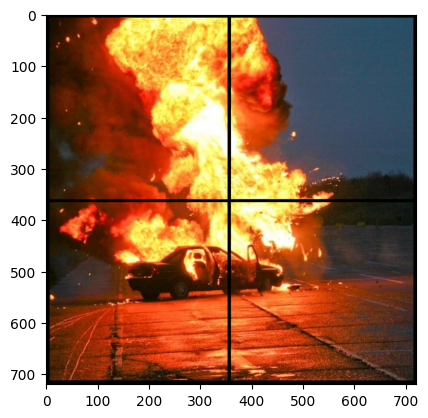

In [395]:
meledak0 = cv2.imread("Assets/Meledak.png")

meledak = cv2.cvtColor(meledak0, cv2.COLOR_BGR2RGB)
plt.imshow(meledak)
print(meledak.shape)

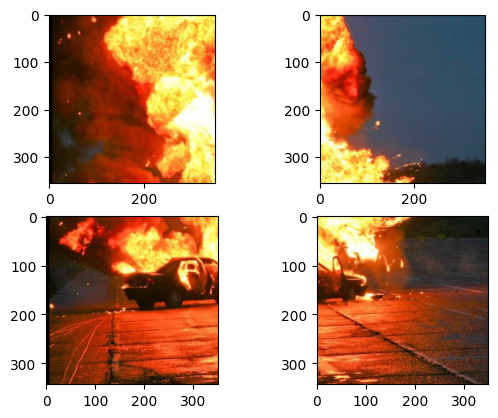

In [396]:
meledak1 = meledak[5:360, 0:350]
meledak2 = meledak[5:360, 360:710]
meledak3 = meledak[367:710, 0:350]
meledak4 = meledak[367:710, 360:710]
plt.subplot(2, 2, 1)
plt.imshow(meledak1)
plt.subplot(2, 2, 2)
plt.imshow(meledak2)
plt.subplot(2, 2, 3)
plt.imshow(meledak3)
plt.subplot(2, 2, 4)
plt.imshow(meledak4)

In [397]:
def merge_image(citra1, citra2, orientation='H'): 
     
    if orientation == 'H':   
        tinggi = max(citra1.shape[0], citra2.shape[0]) 
        lebar_total = citra1.shape[1] + citra2.shape[1] 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi, lebar_total), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi, lebar_total, citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[0:citra2.shape[0], citra1.shape[1]:citra1.shape[1]+citra2.shape[1]] = citra2 
         
    else:   
        tinggi_total = citra1.shape[0] + citra2.shape[0] 
        lebar = max(citra1.shape[1], citra2.shape[1]) 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi_total, lebar), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi_total, lebar, citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[citra1.shape[0]:citra1.shape[0]+citra2.shape[0], 0:citra2.shape[1]] = citra2 
     
    return gabungan

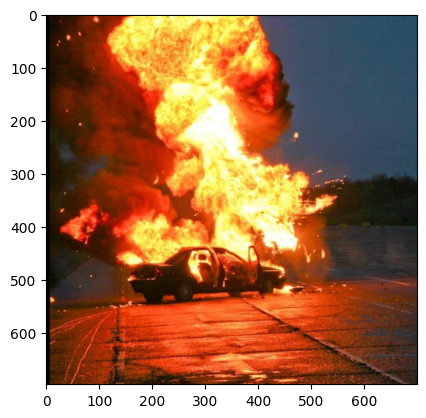

In [398]:
gabung_meledak1 = merge_image(meledak1, meledak2, "H")
gabung_meledak2 = merge_image(meledak3, meledak4, "H")
gabung_meledak = merge_image(gabung_meledak1, gabung_meledak2, "V")
plt.imshow(gabung_meledak)

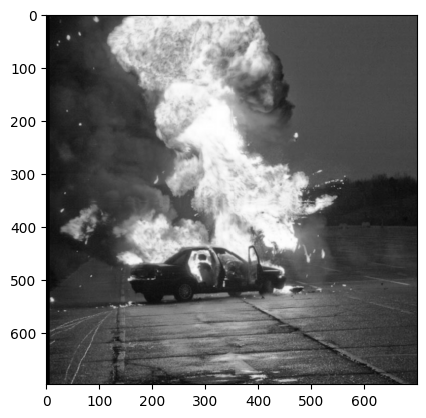

In [399]:
meledakGray = cv2.cvtColor(gabung_meledak, cv2.COLOR_RGB2GRAY)
plt.imshow(meledakGray, cmap='gray')

In [400]:
def buat_hist(citra): 
    histogram = [0] * 256 
 
    height = len(citra) 
    width = len(citra[0]) if height > 0 else 0 
    for i in range(height): 
        for j in range(width): 
            val = int(citra[i][j])   
            histogram[val] += 1
 
    return histogram 

def plot_histogram(histogram, title, ImgColor):
    plt.figure(figsize=(10, 5)) 
    plt.xlabel("Intensitas Piksel") 
    plt.title(title) 
    plt.ylabel("Jumlah Piksel") 
    plt.bar(range(256), histogram, color=ImgColor, width=0.8) 
    plt.show() 

In [401]:
def ekualisasi(citra): 
    height, width = citra.shape
    hist = np.zeros(256, dtype=int)
    
    # Hitung histogram
    for i in range(height):
        for j in range(width):
            hist[citra[i][j]] += 1
    
    # Hitung CDF
    cdf = np.zeros(256, dtype=int) 
    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + hist[i]
    
    # Normalisasi CDF
    cdf_normal = np.round(cdf * 255 / (height * width)).astype(int)
    
    # Terapkan ke setiap pixel
    hasil = np.zeros_like(citra) 
    for i in range(height):
        for j in range(width):
            hasil[i][j] = cdf_normal[citra[i][j]]
    
    return hasil

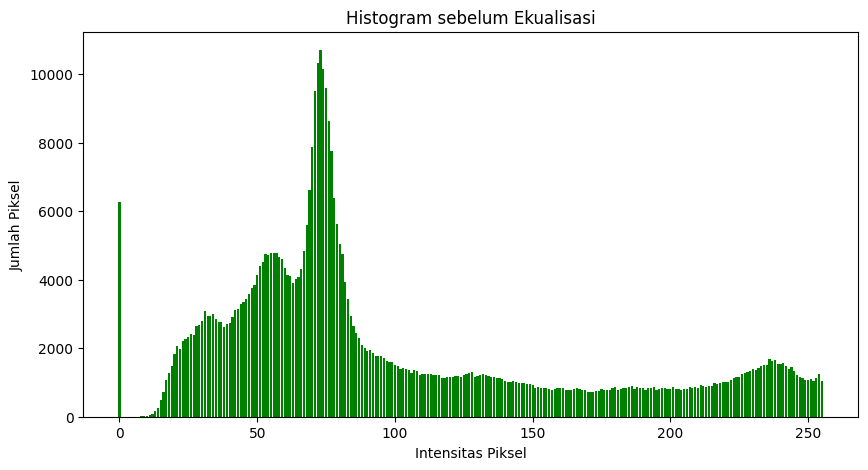

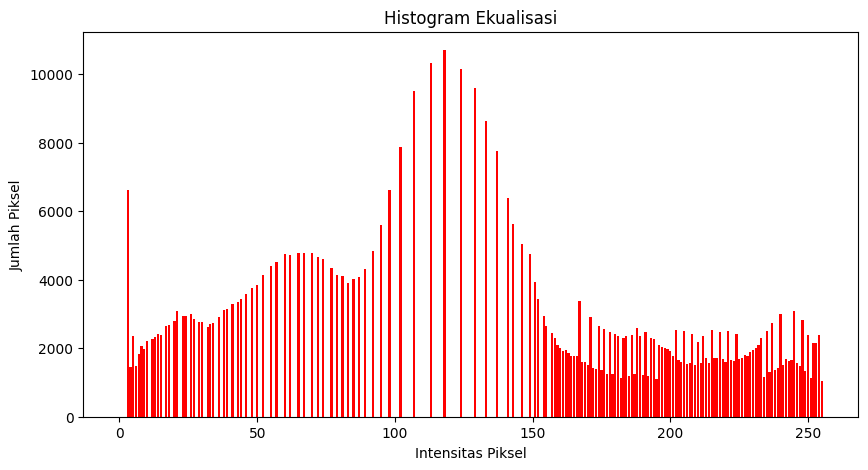

In [402]:
meledakEqual = ekualisasi(meledakGray)
meledak_hist = buat_hist(meledakGray)
plot_meledak_hist = plot_histogram(meledak_hist, "Histogram sebelum Ekualisasi", "green")
meledakEqual_hist = buat_hist(meledakEqual)
plot_meledakEqual_hist = plot_histogram(meledakEqual_hist, "Histogram Ekualisasi", "red")

In [403]:
def spesifikasi_histogram(citra_asal, citra_target): 
    hist_asal = np.zeros(256, dtype=int) 
    hist_target = np.zeros(256, dtype=int) 
 
    # Hitung histogram citra asal
    for i in range(citra_asal.shape[0]):
        for j in range(citra_asal.shape[1]):
            val = int(citra_asal[i][j])
            hist_asal[val] += 1
 
    # Hitung histogram citra target
    for i in range(citra_target.shape[0]):
        for j in range(citra_target.shape[1]):
            val = int(citra_target[i][j])
            hist_target[val] += 1
 
    cdf_asal = np.zeros(256, dtype=float) 
    cdf_target = np.zeros(256, dtype=float) 
 
    cdf_asal[0] = hist_asal[0] 
    cdf_target[0] = hist_target[0] 
 
    # Hitung CDF dari index 1 sampai 255
    for k in range(1, 256):
        cdf_asal[k] = cdf_asal[k-1] + hist_asal[k]
        cdf_target[k] = cdf_target[k-1] + hist_target[k]
 
    cdf_asal = cdf_asal / cdf_asal[-1] 
    cdf_target = cdf_target / cdf_target[-1] 
 
    map_hist = np.zeros(256, dtype=np.uint8) 
 
    # Mapping histogram: cari nilai j dengan selisih CDF terkecil
    for i in range(256):
        selisih_min = abs(cdf_asal[i] - cdf_target[0])
        map_hist[i] = 0
        for j in range(1, 256):
            selisih = abs(cdf_asal[i] - cdf_target[j])
            if selisih < selisih_min:
                selisih_min = selisih
                map_hist[i] = j
 
    height, width = citra_asal.shape 
    hasil = np.zeros((height, width), dtype=np.uint8) 
 
    # Terapkan mapping ke citra asal
    for i in range(height):
        for j in range(width):
            hasil[i][j] = map_hist[int(citra_asal[i][j])]

    return hasil

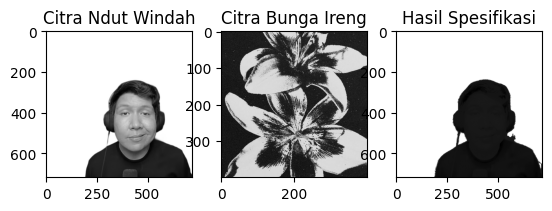

In [404]:
windah0 = cv2.imread("Assets/Windut.png")
windah1 = cv2.cvtColor(windah0, cv2.COLOR_RGB2GRAY)
bunga0 = cv2.imread("Assets/Bunga.png")
bunga = cv2.cvtColor(bunga0, cv2.COLOR_RGB2GRAY)

windah_Equal = ekualisasi(windah1)
win_bung1 = spesifikasi_histogram(windah_Equal, bunga)
plt.subplot(1, 3, 1)
plt.title("Citra Ndut Windah")
plt.imshow(windah1, cmap="gray")
plt.subplot(1, 3, 2)
plt.title("Citra Bunga Ireng")
plt.imshow(bunga, cmap="gray")
plt.subplot(1, 3, 3)
plt.title("Hasil Spesifikasi")
plt.imshow(win_bung1, cmap="gray")

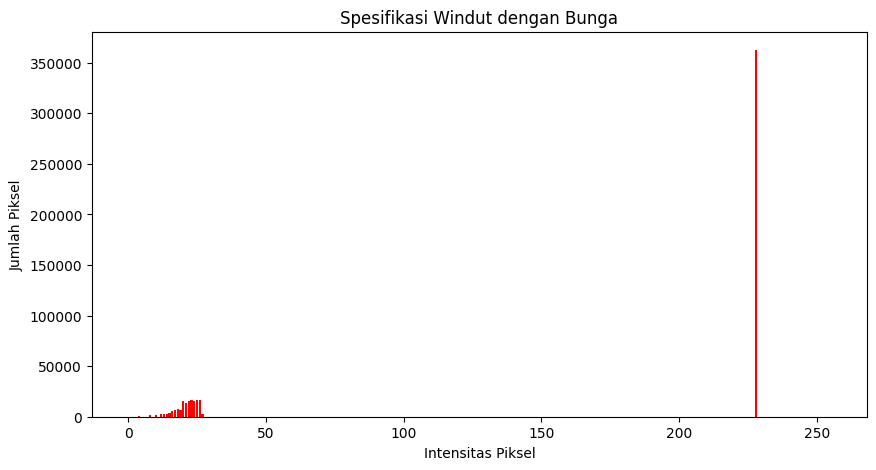

In [405]:
win_bung_hist = buat_hist(win_bung1)
plot_hist_win_bung = plot_histogram(win_bung_hist, "Spesifikasi Windut dengan Bunga", "red")

In [406]:
win_bung = win_bung1[0:,0:700]
windah = windah1[0:,0:700]

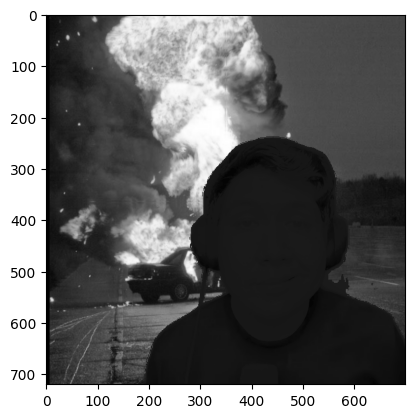

In [407]:
bg = cv2.resize(meledakGray, (windah.shape[1], windah.shape[0]))

hasil = cv2.cvtColor(win_bung, cv2.COLOR_GRAY2BGR)

for i in range(hasil.shape[0]):
    for j in range(hasil.shape[1]):
        if win_bung[i,j] > 200: 
            hasil[i,j] = bg[i,j]
        else :
            hasil[i,j] = win_bung[i, j]

plt.imshow(cv2.cvtColor(hasil, cv2.COLOR_BGR2RGB))
plt.show()

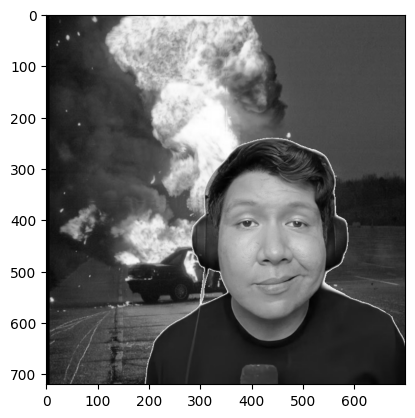

(720, 700, 3)


In [408]:
bg1 = cv2.resize(bg, (windah.shape[1], windah.shape[0]))

hasil_win = cv2.cvtColor(windah, cv2.COLOR_GRAY2BGR)

for i in range(hasil.shape[0]):
    for j in range(hasil.shape[1]):
        if windah[i,j] > 245: 
            hasil_win[i,j] = bg[i,j]
        else :
            hasil_win[i,j] = windah[i, j]

plt.imshow(cv2.cvtColor(hasil_win, cv2.COLOR_BGR2RGB))
plt.show()
print(hasil_win.shape)

(490, 735)


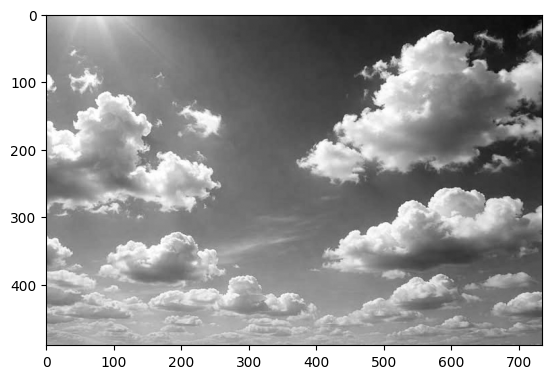

In [409]:
langit0 = cv2.imread("Assets/Langit.png")
langitGray = cv2.cvtColor(langit0, cv2.COLOR_RGB2GRAY)
plt.imshow(langitGray, cmap="gray")
print(langitGray.shape)

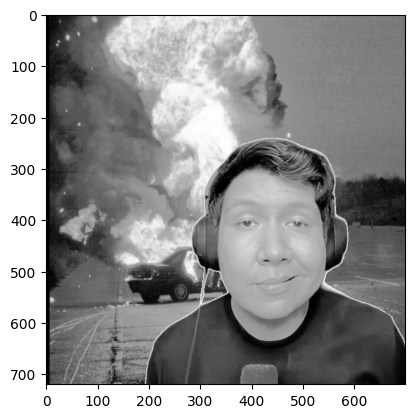

In [410]:
hasil_windah = cv2.cvtColor(hasil_win, cv2.COLOR_BGR2GRAY)
spek_windak = spesifikasi_histogram(hasil_windah, langitGray)
plt.imshow(spek_windak, cmap="gray")

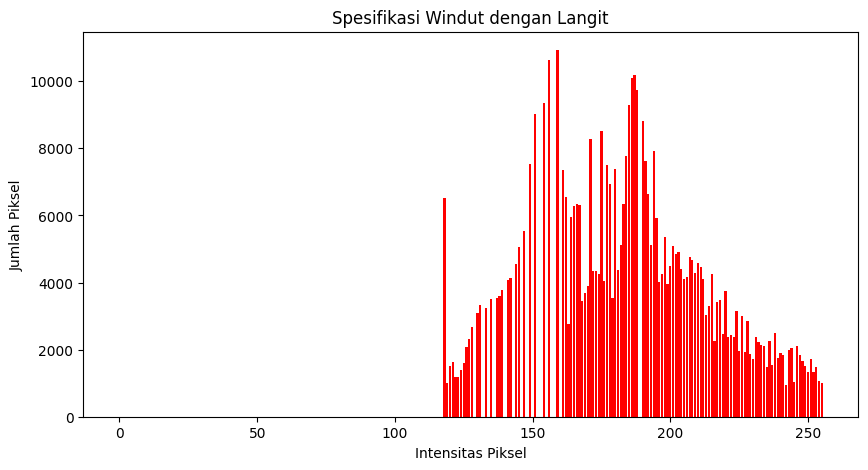

In [411]:
hist_windak = buat_hist(spek_windak)
plot_hist_windak = plot_histogram(hist_windak, "Spesifikasi Windut dengan Langit", "red")

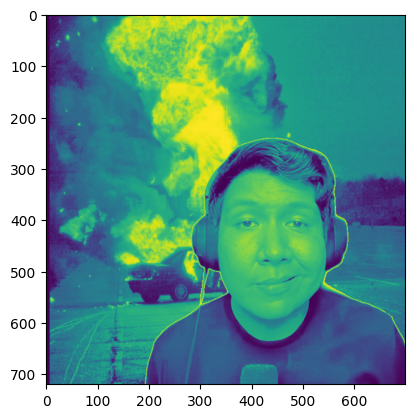

In [412]:
spek_windak_baru = spek_windak
hasil_akhir = spek_windak_baru
plt.imshow(hasil_akhir)

In [414]:
spek_windak_baru1 = cv2.cvtColor(spek_windak, cv2.COLOR_BGR2RGB)
gokilRed, gokilGreen, gokilBlue = cv2.split(spek_windak_baru1)
gokilGray = cv2.cvtColor(spek_windak_baru1, cv2.COLOR_BGR2GRAY)

In [415]:
def merge(blueChannel, greenChannel, redchannel, grayscale, channelChange):

    indexChannel = np.zeros((blueChannel.shape[0], blueChannel.shape[1], 3)).astype(np.uint8)

    if channelChange == 'blue':
        indexChannel[:, :, 0] = redchannel    
        indexChannel[:, :, 1] = greenChannel    
        indexChannel[:, :, 2] = grayscale     
    elif channelChange == 'green':
        indexChannel[:, :, 0] = redchannel
        indexChannel[:, :, 1] = grayscale    
        indexChannel[:, :, 2] = blueChannel
    elif channelChange == 'red':
        indexChannel[:, :, 0] = grayscale 
        indexChannel[:, :, 1] = greenChannel
        indexChannel[:, :, 2] = blueChannel    
    else:
        print("gagal")
    
    return indexChannel

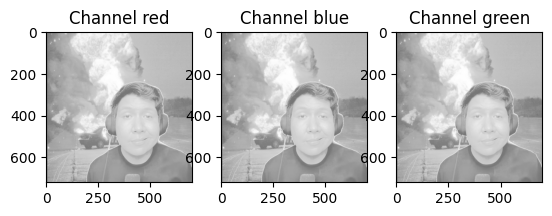

In [419]:
gokilRed_1 = merge(gokilBlue, gokilGreen, gokilRed, gokilGray, "red")
gokilGreen_1 = merge(gokilBlue, gokilGreen, gokilRed, gokilGray, "green")
gokilBlue_1 = merge(gokilBlue, gokilGreen, gokilRed, gokilGray, "blue")

plt.subplot(1, 3, 1)
plt.title("Channel red")
plt.imshow(gokilRed_1, cmap="Reds")
plt.subplot(1, 3, 2)
plt.title("Channel blue")
plt.imshow(gokilBlue_1, cmap="Blues")
plt.subplot(1, 3, 3)
plt.title("Channel green")
plt.imshow(gokilGreen_1, cmap="Greens")